# Exercício **B.6.18**

_Diagrama (Ogata, Figura 6.108): malha unitária negativa com **compensador de avanço de fase** \(G_c(s)=K\dfrac{s+z}{s+p}\) em série com a planta **veículo espacial** \(G_p(s)=\dfrac{1}{s^2}\)._

# Solução completa — **B.6.18**

> **Figura:** veja a **Figura 6.108** no livro (compensador de avanço + planta \(1/s^2\)).

## Enunciado

**Preciso projetar** um compensador de avanço de fase para o sistema em realimentação unitária negativa com

$$
G_p(s)=\frac{1}{s^2},
\qquad
G_c(s)=K\,\frac{s+z}{s+p}\quad (p>z>0),
$$

de forma que os **polos dominantes** em malha fechada fiquem em

$$
s=-1\pm j1.
$$

---

## Passo 1 — Polos dominantes desejados

O par complexo fixa

$$
\omega_n=\sqrt{1^2+1^2}=\sqrt{2}\ \mathrm{rad/s},
\qquad
\zeta=\frac{1}{\omega_n}=\frac{1}{\sqrt{2}}\approx 0{,}707,
$$

e o fator quadrático

$$
s^2+2s+2.
$$

---

## Passo 2 — Equação característica

Com \(H(s)=1\), a malha aberta é

$$
G(s)=G_c(s)G_p(s)=\frac{K(s+z)}{s^2(s+p)}.
$$

A condição \(1+G(s)=0\) dá

$$
s^2(s+p)+K(s+z)=0
\quad\Longrightarrow\quad
s^3+ps^2+Ks+Kz=0.
$$

---

## Passo 3 — Casamento com um terceiro polo real

Como o sistema é de **3ª ordem**, além do par em \(-1\pm j1\) escolho um **terceiro polo** em \(s=-c\) (\(c>0\)) e imponho

$$
(s^2+2s+2)(s+c)=s^3+(c+2)s^2+(2c+2)s+2c.
$$

**Comparando** coeficientes com \(s^3+ps^2+Ks+Kz\):

$$
p=c+2,\qquad K=2c+2,\qquad z=\frac{2c}{2c+2}=\frac{c}{c+1}.
$$

Para **avanço de fase** preciso \(p>z\), o que vale para todo \(c>0\).

**Critério de dominância:** o polo real em \(-c\) deve ser bem mais à esquerda que a parte real \(-1\) do par dominante. Uma escolha usual é \(c\approx 5\) (polo em \(-5\)).

---

## Passo 4 — Parâmetros numéricos (\(c=5\))

$$
z=\frac{5}{6}\approx 0{,}833,\qquad p=7,\qquad K=12.
$$

O compensador fica

$$
G_c(s)=12\,\frac{s+\tfrac{5}{6}}{s+7}.
$$

Em forma \((T_1s+1)/(T_2s+1)\): \(T_1=1/z=1{,}2\), \(T_2=1/p\approx 0{,}143\) (zero em \(-1/T_1\), polo em \(-1/T_2\)).

**Polos em malha fechada:** \(-1\pm j1\) e \(-5\).

---

## Passo 5 — Condição de ângulo (referência geométrica)

No ponto de teste \(s_d=-1+j1\), a planta contribui \(\angle(1/s^2)=90^\circ\). Para estar no lugar das raízes, o compensador deve somar **\(90^\circ\)**:

$$
\angle(s_d+z)-\angle(s_d+p)=90^\circ.
$$

Com \(z=5/6\) e \(p=7\) essa condição é satisfeita; o ganho \(K\) vem da **condição de módulo** \(|G(s_d)|=1\).

---

## Passo 6 — Verificação e gráficos

**Confiro** os polos, traço o **lugar das raízes** da malha aberta compensada e a **resposta ao degrau unitário**.

 SOLUÇÃO — compensador de avanço (c = 5)
 Especificação: polos dominantes em s = -1 ± j1
 Referência: ωn = 1.41421 rad/s,  ζ = 0.707107
 Terceiro polo (casamento): s = -5
 K  = 12
 z  = 0.833333333333   (zero em s = -0.833333)
 p  = 7   (polo do compensador em s = -7)
 Avanço de fase em s_d: 90.0000° (esperado ≈ 90°)
 K por módulo em s_d: 12
 Polos em malha fechada:
   p1: -5.000000 +0.000000 j   |s|=5.000000   ζ≈1.000000
   p2: -1.000000 -1.000000 j   |s|=1.414214   ζ≈0.707107
   p3: -1.000000 +1.000000 j   |s|=1.414214   ζ≈0.707107
 Ganho DC T(0) = 1


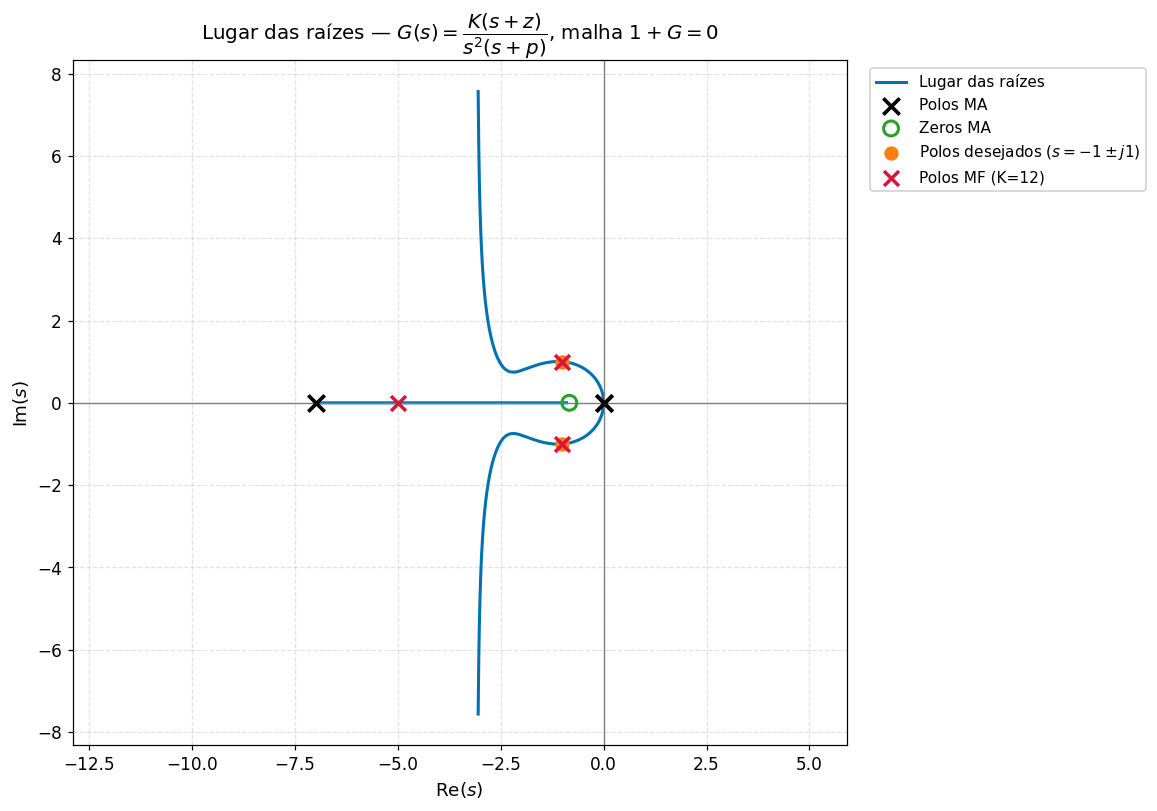

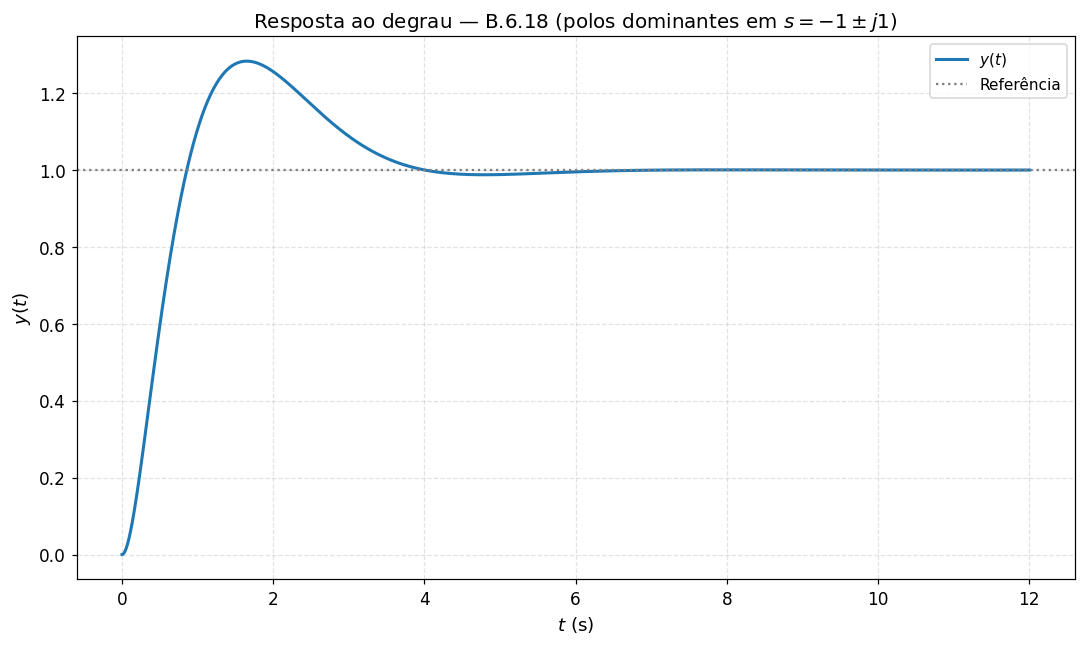

In [1]:
"""
Exercício B.6.18 — compensador de avanço + planta 1/s².
Polos dominantes desejados: s = -1 ± j1.
"""

from __future__ import annotations

import warnings

import control as ct
import matplotlib.pyplot as plt
import numpy as np

warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    module=r"control\.rlocus",
)

plt.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "figure.dpi": 110,
        "font.size": 11,
        "axes.grid": True,
        "grid.linestyle": "--",
        "grid.alpha": 0.35,
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "legend.fontsize": 10,
    }
)

# Polos dominantes do enunciado
SD = -1.0 + 1.0j
OMEGA_N = abs(SD)
ZETA = -SD.real / OMEGA_N


def planta() -> ct.TransferFunction:
    """Planta: veículo espacial Gp(s) = 1/s²."""
    return ct.tf([1.0], [1.0, 0.0, 0.0])


def compensador(k: float, z: float, p: float) -> ct.TransferFunction:
    """Compensador de avanço: Gc(s) = K·(s+z)/(s+p), com p > z."""
    return ct.tf(k * np.array([1.0, z]), np.array([1.0, p]))


def malha_aberta(k: float, z: float, p: float) -> ct.TransferFunction:
    """G(s) = Gc(s)·Gp(s)."""
    return compensador(k, z, p) * planta()


def malha_fechada(k: float, z: float, p: float) -> ct.TransferFunction:
    """Realimentação unitária negativa."""
    return ct.feedback(malha_aberta(k, z, p), 1)


def parametros_por_terceiro_polo(c: float) -> tuple[float, float, float]:
    """
    Casamento (s²+2s+2)(s+c) com s³+ps²+Ks+Kz.

    Retorna (K, z, p) para polo real em s = -c.
    """
    if c <= 0:
        raise ValueError("c deve ser positivo.")
    p = c + 2.0
    k = 2.0 * c + 2.0
    z = c / (c + 1.0)
    return float(k), float(z), float(p)


def ganho_por_modulo(z: float, p: float, s_teste: complex = SD) -> float:
    """K tal que |G(s_teste)| = 1 (condição de módulo no lugar das raízes)."""
    s = s_teste
    return float(abs(s**2 * (s + p) / (s + z)))


def angulo_compensador(z: float, p: float, s_teste: complex = SD) -> float:
    """Fase do termo (s+z)/(s+p) em graus."""
    s = s_teste
    return float(np.degrees(np.angle(s + z) - np.angle(s + p)))


def formatar_polos(polos: np.ndarray) -> None:
    """Lista polos ordenados com parte real/imaginária."""
    polos = np.sort_complex(polos)
    print(" Polos em malha fechada:")
    for i, p in enumerate(polos, start=1):
        mag = abs(p)
        zeta_p = float(-np.real(p) / mag) if mag > 1e-12 else float("nan")
        print(
            f"   p{i}: {np.real(p):+.6f} {np.imag(p):+.6f} j   "
            f"|s|={mag:.6f}   ζ≈{zeta_p:.6f}"
        )


def relatorio(titulo: str, k: float, z: float, p: float, c: float) -> None:
    """Imprime parâmetros e verificações no notebook/console."""
    sep = "=" * 72
    print(sep)
    print(f" {titulo}")
    print(sep)
    print(f" Especificação: polos dominantes em s = -1 ± j1")
    print(f" Referência: ωn = {OMEGA_N:.6g} rad/s,  ζ = {ZETA:.6g}")
    print(f" Terceiro polo (casamento): s = {-c:.6g}")
    print(f" K  = {k:.12g}")
    print(f" z  = {z:.12g}   (zero em s = {-z:.6g})")
    print(f" p  = {p:.12g}   (polo do compensador em s = {-p:.6g})")
    print(f" Avanço de fase em s_d: {angulo_compensador(z, p):.4f}° (esperado ≈ 90°)")
    print(f" K por módulo em s_d: {ganho_por_modulo(z, p):.12g}")
    sys_cl = malha_fechada(k, z, p)
    formatar_polos(ct.poles(sys_cl))
    print(f" Ganho DC T(0) = {float(ct.dcgain(sys_cl)):.12g}")
    print(sep)


def vetor_ganhos_rl(k_ol: float, n: int = 3500) -> np.ndarray:
    """Ganhos para o lugar das raízes de Φ = G/K."""
    k_hi = max(30.0, float(k_ol) * 6.0)
    gain = np.linspace(1e-9, k_hi, n)
    return np.sort(np.unique(np.concatenate([gain, [float(k_ol)]])))


def plot_lugar_raizes(k: float, z: float, p: float) -> None:
    """Lugar das raízes de 1 + K_var·Φ = 0, com Φ = G/K."""
    sys_phi = malha_aberta(1.0, z, p)
    fig, ax = plt.subplots(figsize=(10.5, 7.5))
    rl = ct.root_locus_map(sys_phi, gains=vetor_ganhos_rl(k))
    loci = rl.loci
    for j in range(loci.shape[1]):
        ax.plot(
            np.real(loci[:, j]),
            np.imag(loci[:, j]),
            color="#0072B2",
            lw=2.0,
            label="Lugar das raízes" if j == 0 else None,
        )
    pp = rl.poles
    ax.scatter(
        np.real(pp),
        np.imag(pp),
        s=115,
        c="k",
        marker="x",
        linewidths=2.4,
        zorder=6,
        label="Polos MA",
    )
    zz = rl.zeros
    if len(zz):
        ax.scatter(
            np.real(zz),
            np.imag(zz),
            s=95,
            facecolors="none",
            edgecolors="#2ca02c",
            linewidths=2.0,
            zorder=6,
            label="Zeros MA",
        )
    # Marcação do ponto desejado s = -1 ± j1
    ax.scatter(
        [-1.0, -1.0],
        [1.0, -1.0],
        s=70,
        c="#ff7f0e",
        marker="o",
        zorder=7,
        label=r"Polos desejados ($s=-1\pm j1$)",
    )
    polos_mf = ct.poles(malha_fechada(k, z, p))
    ax.scatter(
        np.real(polos_mf),
        np.imag(polos_mf),
        s=95,
        c="crimson",
        marker="x",
        linewidths=2.3,
        zorder=8,
        label=f"Polos MF (K={k:g})",
    )
    ax.axhline(0.0, color="gray", lw=0.9)
    ax.axvline(0.0, color="gray", lw=0.9)
    ax.set_title(
        r"Lugar das raízes — $G(s)=\dfrac{K(s+z)}{s^2(s+p)}$, malha $1+G=0$"
    )
    ax.set_xlabel(r"$\mathrm{Re}(s)$")
    ax.set_ylabel(r"$\mathrm{Im}(s)$")
    ax.set_aspect("equal", adjustable="datalim")
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), framealpha=0.96)
    fig.subplots_adjust(left=0.07, right=0.74, top=0.92, bottom=0.09)


def plot_degrau(k: float, z: float, p: float, titulo: str) -> None:
    """Resposta ao degrau unitário da malha fechada."""
    sys_cl = malha_fechada(k, z, p)
    t = np.linspace(0.0, 12.0, 4000)
    tout, yout = ct.step_response(sys_cl, t)
    fig, ax = plt.subplots()
    ax.plot(tout, yout, lw=2.0, label=r"$y(t)$")
    ax.axhline(1.0, color="gray", ls=":", lw=1.5, label="Referência")
    ax.set_title(titulo)
    ax.set_xlabel(r"$t$ (s)")
    ax.set_ylabel(r"$y(t)$")
    ax.legend(loc="best")
    plt.tight_layout()


# --- Solução principal: terceiro polo em s = -5 (c = 5) ---
C_DOM = 5.0
K, Z, P = parametros_por_terceiro_polo(C_DOM)
relatorio("SOLUÇÃO — compensador de avanço (c = 5)", K, Z, P, C_DOM)

plot_lugar_raizes(K, Z, P)
plt.show()

plot_degrau(
    K,
    Z,
    P,
    "Resposta ao degrau — B.6.18 (polos dominantes em $s=-1\\pm j1$)",
)
plt.show()